In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
data = pd.read_csv('datos/bf_dataset.csv')

In [5]:
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


# 1

## a)

    Tenemos que las variables numéricas son:
    - ``User ID``
    - ``Ocupation``
    - ``Marital_Status``
    - ``Product_Category_1``
    - ``Product_Category_2``
    - ``Product_Category_3``
    - ``Purchase``

    Mientras que las variables categoricas son:
    - ``Product_ID``
    - ``Gender``
    - ``Age``
    - ``City_Category``
    - ``Stay_In_Current_City_Years``

    Pero algo a tener en cuenta es que categorias como ``Product_ID`` parecen arrancar siempre con P al inicio, pero pueden identificarse como numéricas si se elimina la P. (supongo que es de producto)

    ``Age`` es un rango de edades, podría imputarse en categorías numéricas. Siendo 0 aquella menores de 18 años, 1, 2, etc para lo que sigue. 

    Despues varias categorías como ``City_Category`` o ``Ocupation`` estan codificadas, que ahora mismo no sabría que significan. 

Las variables demográficas son:
- ``Gender``
- ``Age``
- ``Ocupation``
- ``Marital_Status``

Las variables geográficas son:
- ``City_Category``
- ``Stay_In_Curret_City_Years``

Las variables de producto son: 
- ``Product_Category_1``
- ``Product_Category_2``
- ``Product_Category_3``

Identificadores
- ``Product_ID`` (De producto)
- ``User_ID`` (De cliente)

Capaz las variables de comportamiento de compra pueden ser:
- ``Stay_In_Curret_City_Years`` (Un recienn mudado compra más)
- ``Marital_Status`` (Cumpleaños, aniversarios, etc)
- ``Purchase`` (Cuanto gastó/o podría gastar)
- ``Age`` (Hay rangos de edad que más compran por poder adquisitivo)
- ``Gender`` 

* 

De igual manera el comportamiento de compra, mientras más lo pieso puede llegar a ser todas las categorias.

In [13]:
attributes = data.columns

## b)

In [19]:
print('Existen',data[attributes[0]].unique().shape[0],'usuarios distintos')

Existen 5891 usuarios distintos


A cada cliente lo podemos identificar por su ID, por lo que podemos ver que existen 5891 clientes distintos.

## c)

No tenemos información temporal, lo único que tenemos es la cantidad de Items que compró y el precio de cada item. Cada fila es un item comprado, pero no sabemos si los compró todos juntos o si los compró en períodos de tiempo diferente.

Como no tenemos una serie temporal no sabemos bien cuando podemos hacer ofertas a la persona. A principio de mes, segunda quincena, fin de mes? Cuando tienen dinero la persona? Cuando es el cumpleaños de su pareja por ejemplo? 

Lo que compró fue por alguna fecha especial y aprovecho las ofertas? o porque venía esperando comprar eso y lo compro en oferta? Siempre compra?

Son muchas preguntas que al no tener ningún dato temporal no lo sabemos. 

El único dato temporal que podemos llegar a tener es el de cuanto tiempo hace que vive donde vive. Capaz hizo muchas compras de mudanza, compro cosas más grandes. O capaz que esa gente gasta igual que los que hace mucho que viven ahí. 

A priori no tenemos ningún indicio temporal en el set de datos. Así que no podemos saber si hay momentos que el cliente compra mas o menos. 

## d)

In [21]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Si tenemos datos nulos, solamente en ``Product_Category_2`` y ``Product_Category_3`` . Esto puede ser solamente porque son sub categorías del producto. 

(Poner /  ver los porcentajes de nulos/completos)

Esto a mi parecer no sería ningún impedimento. Supogamos que tenemos que alguien compra un tele. Si es plano, curvo, OLED, LCD etc etc ... capaz no es taaaan importante, como que compro un tele. Capaz. Con la info que tenemos para una prediccion inicial un product category 1 es suficiente. Capas tambien que si es ropa capas si tengamos las demás categorias completas, si son muebles capas menos categorias. No se ... pienso. 

Los productos que no tienen categoria 2 o 3 es porque no tienen asignada una sub-categoria.

## e)

In [23]:
print('Existen',data[attributes[8]].unique().shape[0],'categorias distintas')
print('Existen',data[attributes[1]].unique().shape[0],'productos distintas')


Existen 20 categorias distintas
Existen 3631 productos distintas


Si lo que queremos es *predecir el monto de compra de un cliente para distintos productos**, 

In [ ]:
print('Existen',data[attributes[-1]].unique().shape[0],'precios distintas')


Existen 18105 productos distintas


In [25]:
attributes[-1]

'Purchase'

Si. La columna `Purchase` es justamente nuestra columna objetivo para hacer aprendizaje supervisado. 

Y representa lo que pago cada cliente por el producto comprado (sea cual sea y la cantidad que fue)


# 2

## a

In [10]:
data.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [7]:
categorias_numericas = data.select_dtypes(include=[np.number])

In [12]:
categorias_numericas.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [15]:
purchase_stats = data['Purchase'].agg(['min','max','mean','median'])
purchase_quantiles = data['Purchase'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print(purchase_stats)
print()
print(purchase_quantiles)

min          12.000000
max       23961.000000
mean       9263.968713
median     8047.000000
Name: Purchase, dtype: float64

0.25     5823.0
0.50     8047.0
0.75    12054.0
0.90    16317.0
0.95    19336.0
0.99    20665.0
Name: Purchase, dtype: float64


## b

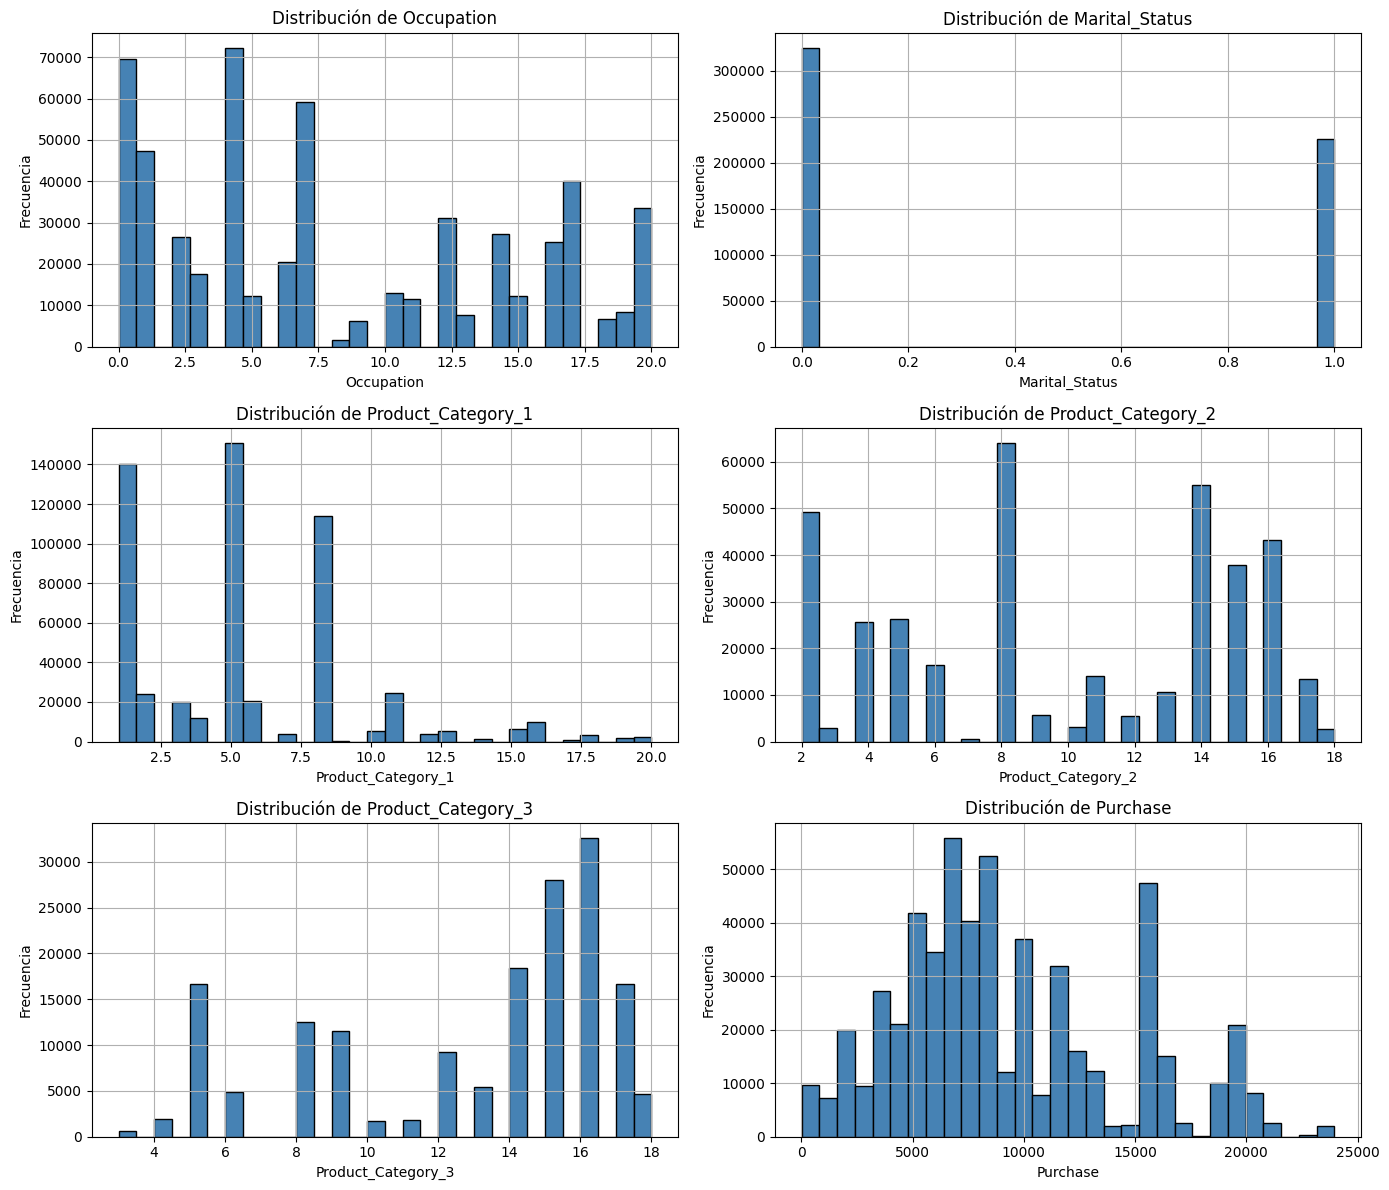

In [16]:
cols_numericas = ['Occupation', 'Marital_Status', 'Product_Category_1',
                   'Product_Category_2', 'Product_Category_3', 'Purchase']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    data[col].dropna().hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

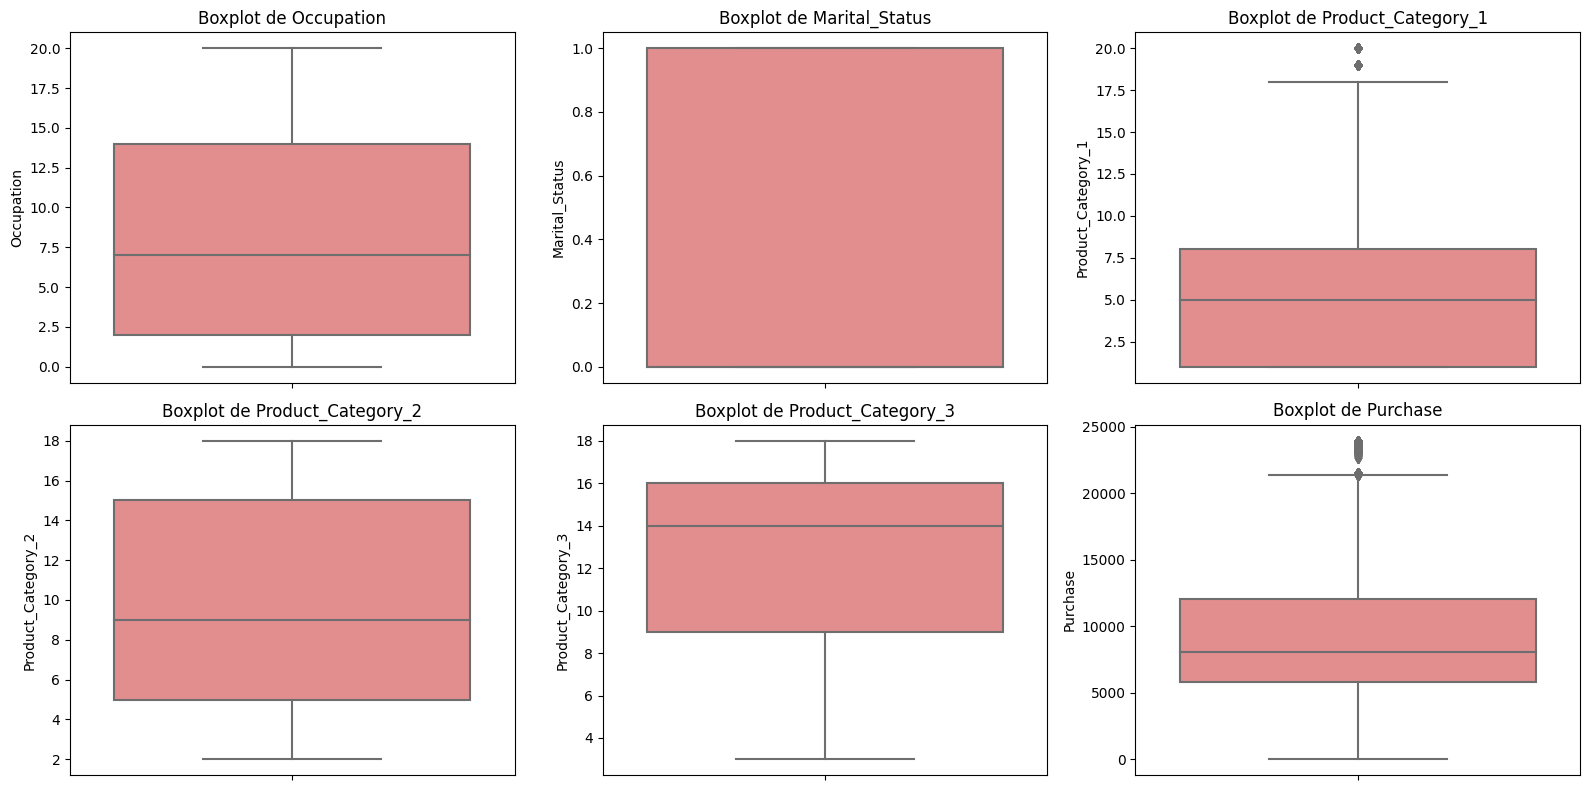

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(y=data[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

## c

Skewness de Purchase: 0.6001400037087128
Kurtosis de Purchase: -0.3383775655851702


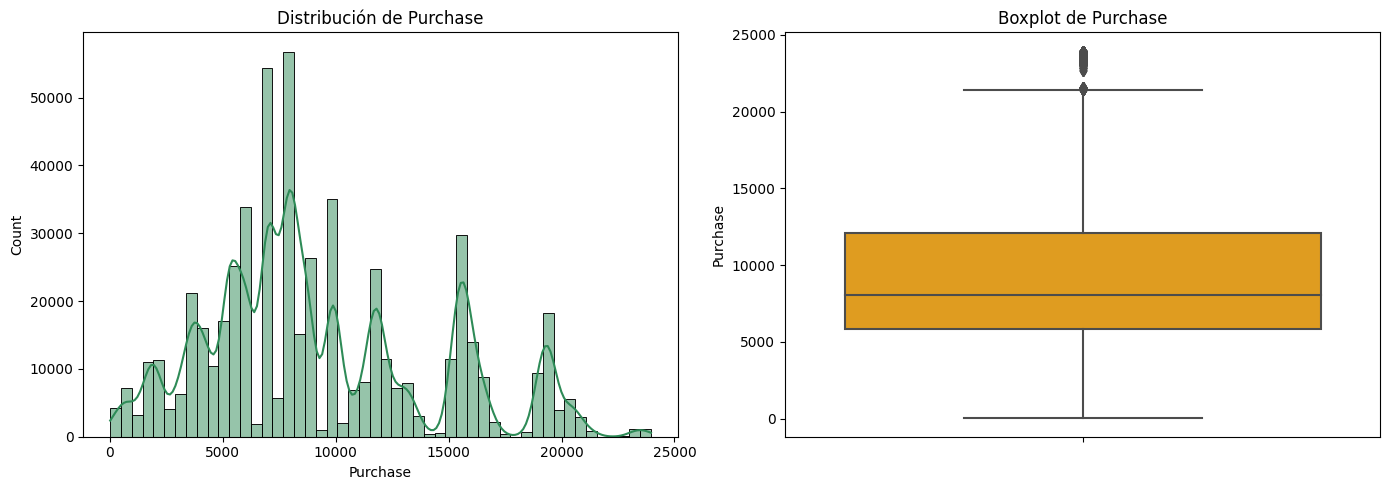

In [18]:
print('Skewness de Purchase:', data['Purchase'].skew())
print('Kurtosis de Purchase:', data['Purchase'].kurt())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['Purchase'], bins=50, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribución de Purchase')

sns.boxplot(y=data['Purchase'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot de Purchase')

plt.tight_layout()
plt.show()

In [19]:
Q1 = data['Purchase'].quantile(0.25)
Q3 = data['Purchase'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = data[(data['Purchase'] < lim_inf) | (data['Purchase'] > lim_sup)]
print(f'Cantidad de outliers: {outliers.shape[0]} ({outliers.shape[0]/data.shape[0]*100:.2f}%)')
print(f'Límite inferior: {lim_inf:.2f} | Límite superior: {lim_sup:.2f}')

Cantidad de outliers: 2677 (0.49%)
Límite inferior: -3523.50 | Límite superior: 21400.50


## d

Gender
M    4225
F    1666
Name: count, dtype: int64
Gender
M    71.719572
F    28.280428
Name: proportion, dtype: float64


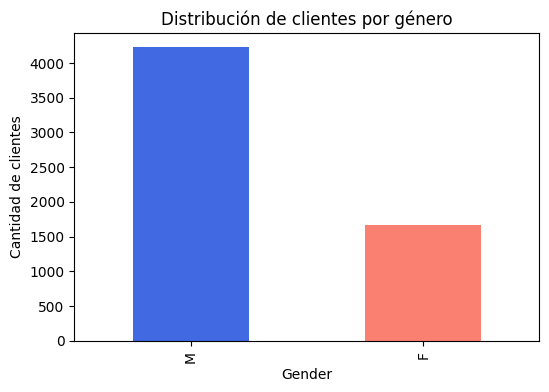

In [20]:
clientes_unicos = data.drop_duplicates(subset='User_ID')

genero_counts = clientes_unicos['Gender'].value_counts()
genero_pct = clientes_unicos['Gender'].value_counts(normalize=True) * 100

print(genero_counts)
print(genero_pct)

genero_counts.plot(kind='bar', color=['royalblue', 'salmon'], figsize=(6,4))
plt.title('Distribución de clientes por género')
plt.ylabel('Cantidad de clientes')
plt.show()

              mean  median         sum   count
Age                                           
51-55  9534.808031  8130.0   367099644   38501
55+    9336.280459  8105.5   200767375   21504
36-45  9331.350695  8061.0  1026569884  110013
26-35  9252.690633  8030.0  2031770578  219587
46-50  9208.625697  8036.0   420843403   45701
18-25  9169.663606  8027.0   913848675   99660
0-17   8933.464640  7986.0   134913183   15102


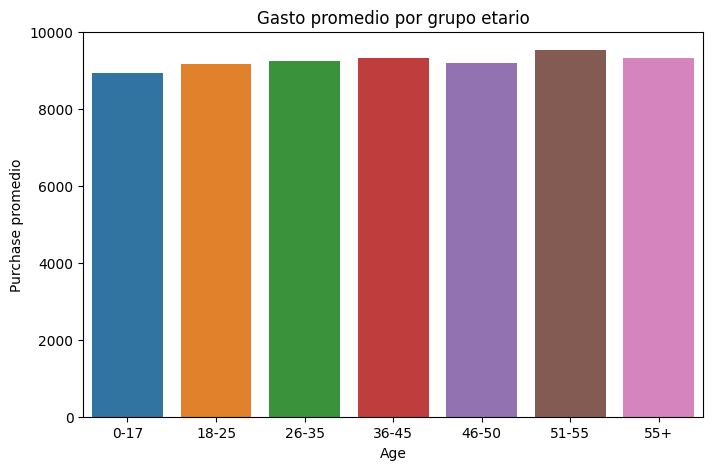

In [21]:
gasto_por_edad = data.groupby('Age')['Purchase'].agg(['mean', 'median', 'sum', 'count']).sort_values('mean', ascending=False)
print(gasto_por_edad)

plt.figure(figsize=(8,5))
sns.barplot(x=gasto_por_edad.index, y=gasto_por_edad['mean'], order=sorted(data['Age'].unique()))
plt.title('Gasto promedio por grupo etario')
plt.ylabel('Purchase promedio')
plt.show()

City_Category
C    3139
B    1707
A    1045
Name: count, dtype: int64


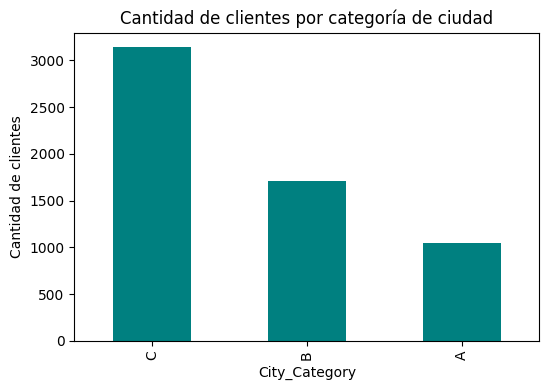

In [22]:
clientes_por_ciudad = clientes_unicos['City_Category'].value_counts()
print(clientes_por_ciudad)

clientes_por_ciudad.plot(kind='bar', color='teal', figsize=(6,4))
plt.title('Cantidad de clientes por categoría de ciudad')
plt.ylabel('Cantidad de clientes')
plt.show()

In [23]:
print('Cantidad de productos únicos:', data['Product_ID'].nunique())

Cantidad de productos únicos: 3631


Product_Category_1 más frecuentes:
Product_Category_1
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
Name: count, dtype: int64


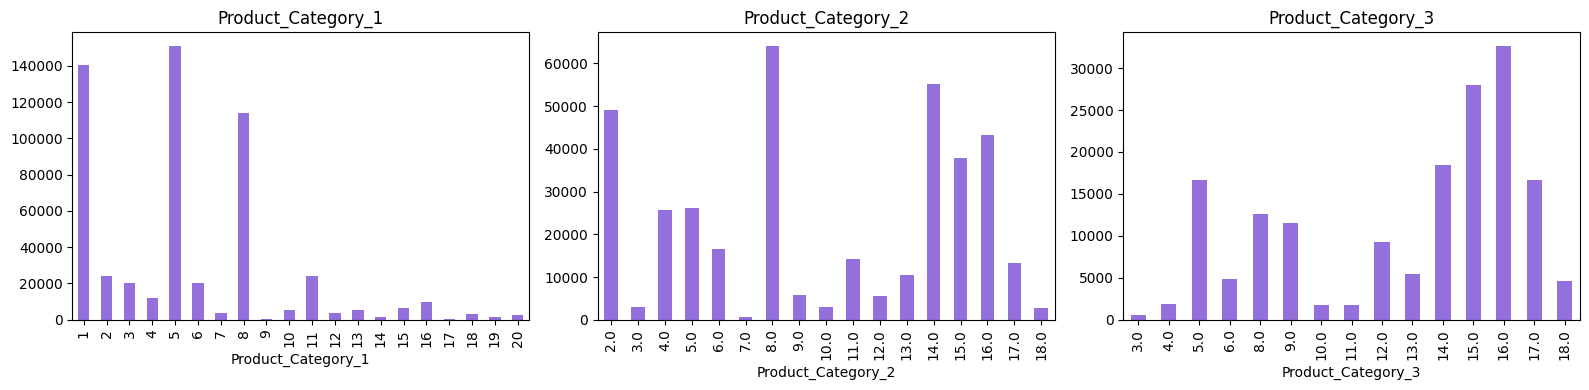

In [24]:
print('Product_Category_1 más frecuentes:')
print(data['Product_Category_1'].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16,4))
for i, col in enumerate(['Product_Category_1', 'Product_Category_2', 'Product_Category_3']):
    data[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='mediumpurple')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [25]:
combo_gasto = (data.groupby(['Product_Category_1', 'Product_Category_2'])['Purchase']
               .mean()
               .sort_values(ascending=False)
               .head(15))
print(combo_gasto)

Product_Category_1  Product_Category_2
10                  14.0                  20113.225000
                    16.0                  19704.598506
                    13.0                  19610.779787
                    15.0                  19475.085308
                    11.0                  19206.000000
15                  17.0                  18951.667571
6                   10.0                  16772.858116
7                   17.0                  16041.265306
6                   16.0                  15973.824675
                    8.0                   15837.501698
1                   18.0                  15822.800000
9                   15.0                  15530.239609
7                   8.0                   15414.857143
14                  16.0                  14449.395639
1                   8.0                   14425.534225
Name: Purchase, dtype: float64


In [26]:
top_productos_total = data.groupby('Product_ID')['Purchase'].sum().sort_values(ascending=False).head(10)
top_productos_promedio = data.groupby('Product_ID')['Purchase'].mean().sort_values(ascending=False).head(10)

print('Top productos por monto total vendido:')
print(top_productos_total)
print()
print('Top productos por monto promedio de compra:')
print(top_productos_promedio)

Top productos por monto total vendido:
Product_ID
P00025442    27995166
P00110742    26722309
P00255842    25168963
P00059442    24338343
P00184942    24334887
P00112142    24216006
P00110942    23639564
P00237542    23425576
P00057642    23102780
P00010742    22164153
Name: Purchase, dtype: int64

Top productos por monto promedio de compra:
Product_ID
P00086242    21256.505495
P00085342    20980.268116
P00200642    20468.773234
P00116142    20463.791277
P00119342    20448.756494
P00117642    20400.283544
P00074542    20323.000000
P00341542    20291.000000
P00052842    20141.139511
P00087042    20113.225000
Name: Purchase, dtype: float64


In [27]:
sin_cat2 = data['Product_Category_2'].isnull()
sin_cat3 = data['Product_Category_3'].isnull()

print('Gasto promedio CON Category_2:', data.loc[~sin_cat2, 'Purchase'].mean())
print('Gasto promedio SIN Category_2:', data.loc[sin_cat2, 'Purchase'].mean())
print()
print('Gasto promedio CON Category_3:', data.loc[~sin_cat3, 'Purchase'].mean())
print('Gasto promedio SIN Category_3:', data.loc[sin_cat3, 'Purchase'].mean())

Gasto promedio CON Category_2: 10069.02083255851
Gasto promedio SIN Category_2: 7518.695389258111

Gasto promedio CON Category_3: 11658.114979528957
Gasto promedio SIN Category_3: 8221.83694327679


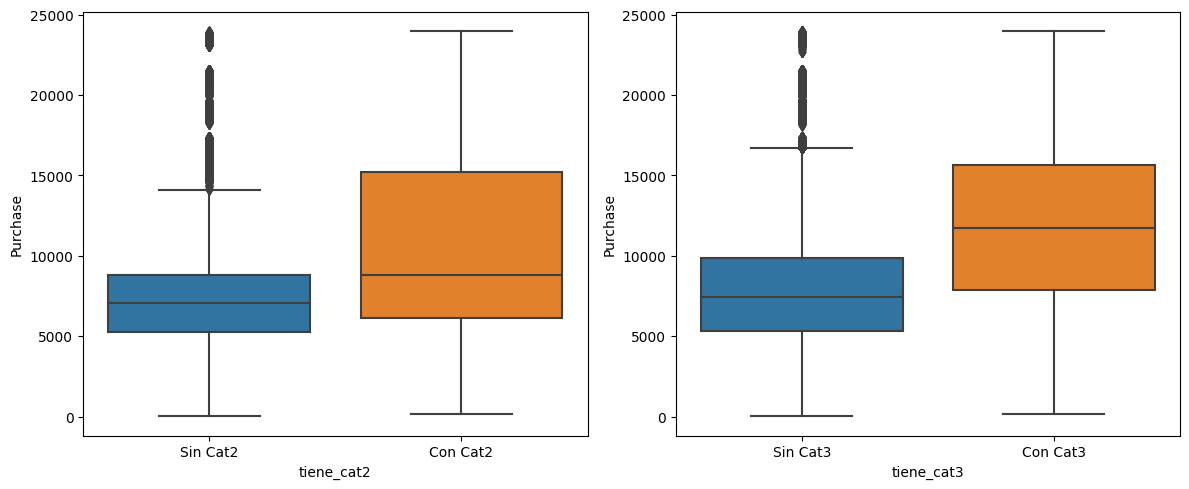

In [28]:
data['tiene_cat2'] = np.where(data['Product_Category_2'].isnull(), 'Sin Cat2', 'Con Cat2')
data['tiene_cat3'] = np.where(data['Product_Category_3'].isnull(), 'Sin Cat3', 'Con Cat3')

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x='tiene_cat2', y='Purchase', data=data, ax=axes[0])
sns.boxplot(x='tiene_cat3', y='Purchase', data=data, ax=axes[1])
plt.tight_layout()
plt.show()

## e

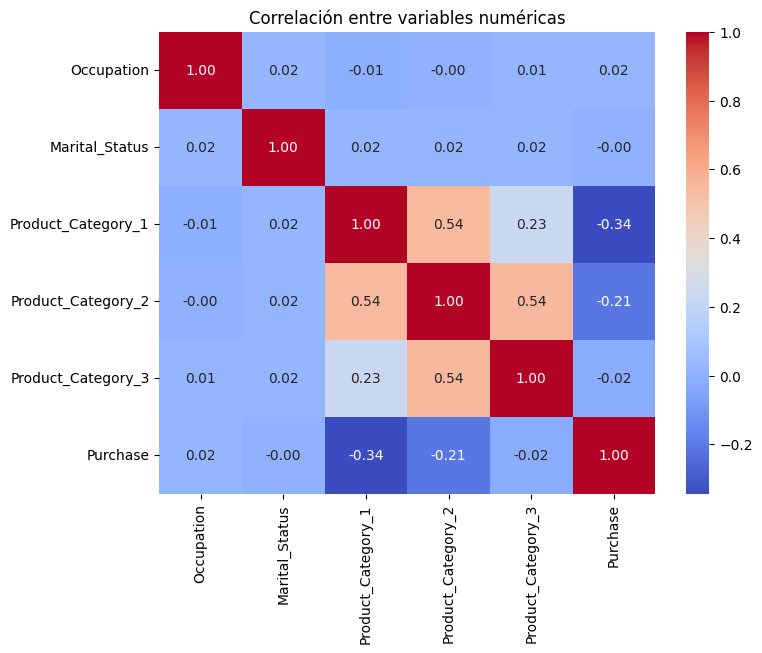

In [29]:
corr = data[['Occupation','Marital_Status','Product_Category_1',
             'Product_Category_2','Product_Category_3','Purchase']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

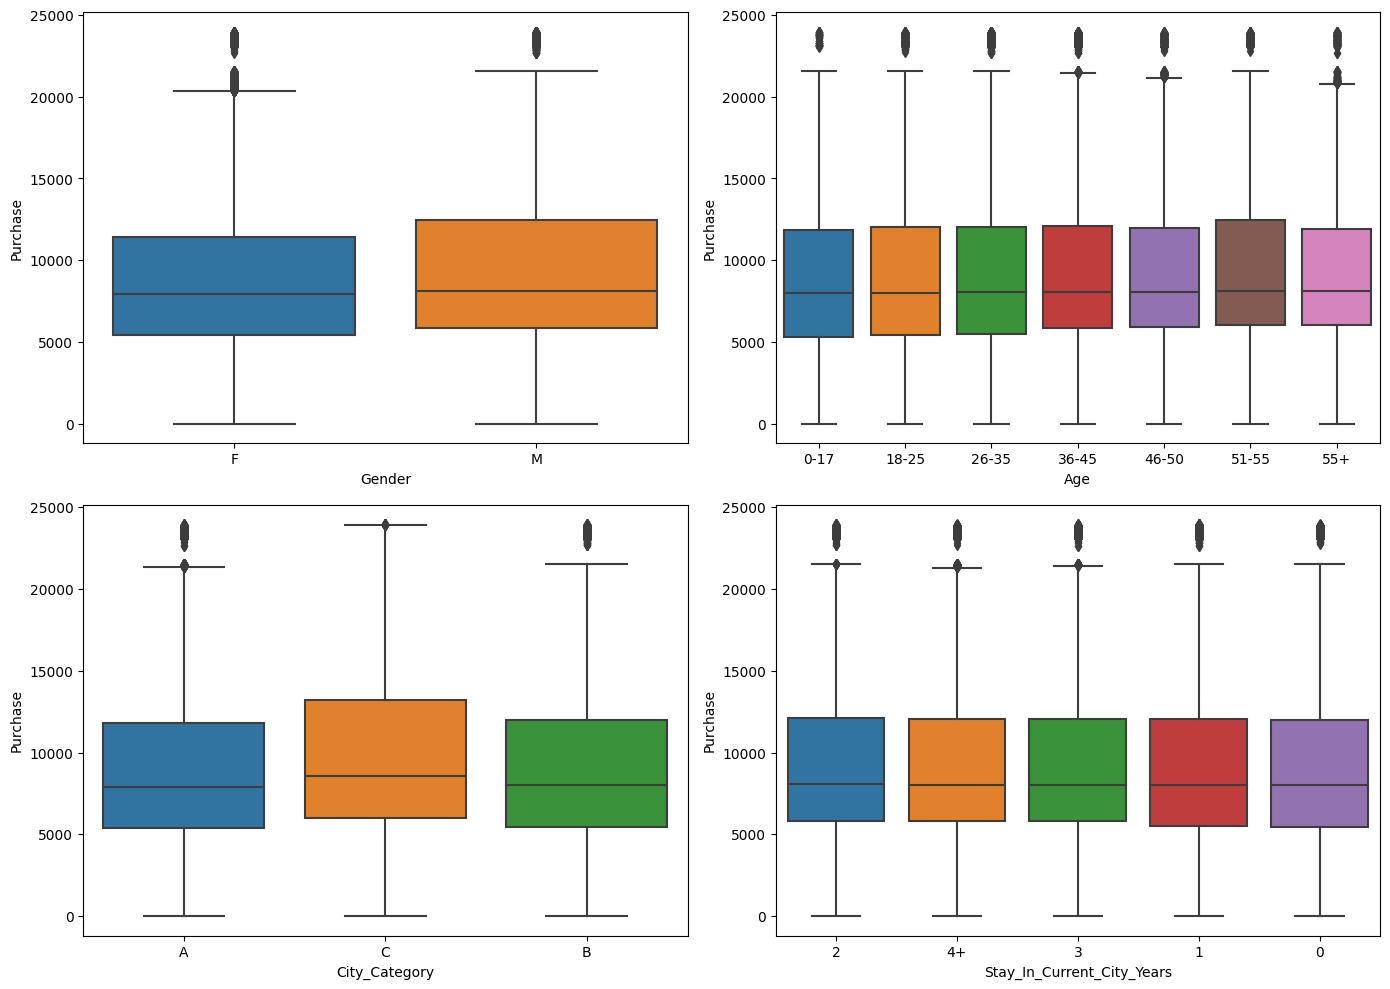

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.boxplot(x='Gender', y='Purchase', data=data, ax=axes[0,0])
sns.boxplot(x='Age', y='Purchase', data=data, ax=axes[0,1], order=sorted(data['Age'].unique()))
sns.boxplot(x='City_Category', y='Purchase', data=data, ax=axes[1,0])
sns.boxplot(x='Stay_In_Current_City_Years', y='Purchase', data=data, ax=axes[1,1])

plt.tight_layout()
plt.show()

## f

In [31]:
data['Purchase_Segment'] = pd.qcut(data['Purchase'], q=3, labels=['Bajo', 'Medio', 'Alto'])
print(data['Purchase_Segment'].value_counts())

Purchase_Segment
Bajo     183428
Medio    183325
Alto     183315
Name: count, dtype: int64


In [32]:
caracterizacion = data.groupby('Purchase_Segment').agg(
    gasto_promedio=('Purchase', 'mean'),
    gasto_min=('Purchase', 'min'),
    gasto_max=('Purchase', 'max'),
    pct_hombres=('Gender', lambda x: (x == 'M').mean() * 100),
    edad_moda=('Age', lambda x: x.mode()[0]),
    ciudad_moda=('City_Category', lambda x: x.mode()[0]),
    categoria1_moda=('Product_Category_1', lambda x: x.mode()[0])
)
print(caracterizacion)

                  gasto_promedio  gasto_min  gasto_max  pct_hombres edad_moda  \
Purchase_Segment                                                                
Bajo                 4287.234185         12       6915    73.599996     26-35   
Medio                8254.445569       6916      10068    72.607119     26-35   
Alto                15253.349240      10069      23961    79.725609     26-35   

                 ciudad_moda  categoria1_moda  
Purchase_Segment                               
Bajo                       B                5  
Medio                      B                5  
Alto                       B                1  


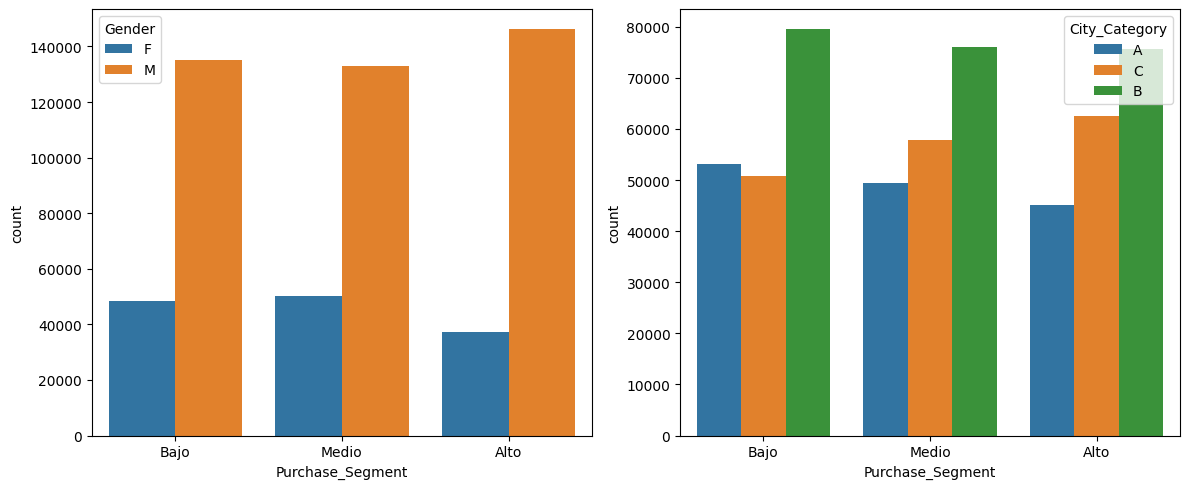

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='Purchase_Segment', hue='Gender', data=data, ax=axes[0])
sns.countplot(x='Purchase_Segment', hue='City_Category', data=data, ax=axes[1])
plt.tight_layout()
plt.show()

## g

In [34]:
from scipy import stats

variables_categoricas = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years',
                          'Marital_Status', 'Product_Category_1']

for var in variables_categoricas:
    grupos = [g['Purchase'].values for _, g in data.groupby(var)]
    f_stat, p_value = stats.f_oneway(*grupos)
    print(f'{var}: F={f_stat:.2f}, p-value={p_value:.4f}')

Gender: F=2010.44, p-value=0.0000
Age: F=40.58, p-value=0.0000
City_Category: F=1130.75, p-value=0.0000
Stay_In_Current_City_Years: F=9.38, p-value=0.0000
Marital_Status: F=0.12, p-value=0.7311
Product_Category_1: F=50703.97, p-value=0.0000
